# Function 5 – Next Evaluation (Week 8)

Load all observed data (including Week 7), identify the current maximum (incumbent), run exploitative Bayesian Optimization (β=0), and save the suggested next point.

In [10]:
def validate_progress(y_observed, function_name=None, recent_k=3, tol_frac=0.01, min_improve_frac=0.05):
    """
    Deterministic progress check for maximizing an objective (higher is better).

    Args:
        y_observed: list/array of observed y values.
        recent_k: how many recent points to consider.
        tol_frac: how close recent best must be to best overall to call it "near best"
                  (fraction of |best_overall|, handles negatives safely).
        min_improve_frac: if near best, require at least this fractional improvement vs previous point
                          to avoid calling it plateau.

    Returns:
        status: 'improving' | 'plateau' | 'stuck' | 'insufficient_data'
        message: explanation
        flag: True if concerning
    """
    y = np.asarray(y_observed, dtype=float)
    n = len(y)

    if n < recent_k + 1:
        return "insufficient_data", "Not enough data to validate", False

    recent = y[-recent_k:]
    best_overall = float(np.max(y))
    best_recent = float(np.max(recent))

    scale = max(abs(best_overall), 1e-12)
    close_tol = tol_frac * scale
    near_best = (best_overall - best_recent) <= close_tol

    prev = float(y[-2])
    last = float(y[-1])
    step_scale = max(abs(prev), 1e-12)
    step_improve_frac = (last - prev) / step_scale

    if near_best:
        if step_improve_frac >= min_improve_frac:
            return "improving", f"Near best and still improving. Best={best_overall:.6f}, last={last:.6f}", False
        else:
            return "plateau", f"Near best but improvements are small. Best={best_overall:.6f}, last={last:.6f}", True

    recent_trend = float(recent[-1] - recent[0])
    if recent_trend > 0:
        return "improving", f"Recent trend is positive, moving toward best={best_overall:.6f}", False
    else:
        return "stuck", f"Recent trend is negative and not near best. Best={best_overall:.6f}, recent_best={best_recent:.6f}", True


In [11]:
import numpy as np
from pathlib import Path

import sys
sys.path.append('../..')

from scripts.utils.data_utils import (
    load_initial_data,
    load_week1_data,
    load_week2_data,
    load_week3_data,
    load_week4_data,
    _load_latest_week_data,
    plot_tsne_with_distribution,
)

from scripts.bayesian_optimisation import SimpleBayesianOptimization

base_dir = Path('../../data/initial_data')
week1_dir = Path('../../data/week1')
week2_dir = Path('../../data/week2')
week3_dir = Path('../../data/week3')
week4_dir = Path('../../data/week4')
week5_dir = Path('../../data/week5')
week6_dir = Path('../../data/week6')
week7_dir = Path('../../data/week7')

initial_data = load_initial_data(base_dir)
week1_data = load_week1_data(week1_dir)
week2_data = load_week2_data(week2_dir)
week3_data = load_week3_data(week3_dir)
week4_data = load_week4_data(week4_dir)
week5_data = _load_latest_week_data(week5_dir, 'Week 5')
week6_data = _load_latest_week_data(week6_dir, 'Week 6')
week7_data = _load_latest_week_data(week7_dir, 'Week 7')

function_name = 'function_5'
original_inputs = initial_data[function_name]['inputs']
original_outputs = initial_data[function_name]['outputs']
week1_input = week1_data[function_name]['input']
week1_output = week1_data[function_name]['output']
week2_input = week2_data[function_name]['input']
week2_output = week2_data[function_name]['output']
week3_input = week3_data[function_name]['input']
week3_output = week3_data[function_name]['output']
week4_input = week4_data[function_name]['input']
week4_output = week4_data[function_name]['output']
week5_input = week5_data[function_name]['input']
week5_output = week5_data[function_name]['output']
week6_input = week6_data[function_name]['input']
week6_output = week6_data[function_name]['output']
week7_input = week7_data[function_name]['input']
week7_output = week7_data[function_name]['output']

X_observed = np.vstack([
    original_inputs,
    week1_input.reshape(1, -1),
    week2_input.reshape(1, -1),
    week3_input.reshape(1, -1),
    week4_input.reshape(1, -1),
    week5_input.reshape(1, -1),
    week6_input.reshape(1, -1),
    week7_input.reshape(1, -1),
])
y_observed = np.concatenate([
    original_outputs,
    np.array([week1_output, week2_output, week3_output, week4_output, week5_output, week6_output, week7_output]),
])

best_idx = np.argmax(y_observed)
incumbent_input = X_observed[best_idx]
incumbent_output = y_observed[best_idx]

print('=' * 60)
print('FUNCTION 5 – CURRENT MAXIMUM (INCUMBENT)')
print('=' * 60)
print(f'Incumbent input (best-performing configuration): {incumbent_input}')
print(f'Incumbent output (observed maximum):            {incumbent_output:.6f}')
print(f'Number of observations:                         {len(y_observed)}')

# Progress validation
status, message, flag = validate_progress(y_observed, function_name)
print(f"\n{'⚠️ ' if flag else '✓ '}PROGRESS STATUS: {status.upper()}")
print(f"  {message}")
print('=' * 60)

FUNCTION 5 – CURRENT MAXIMUM (INCUMBENT)
Incumbent input (best-performing configuration): [0.937239 0.959791 0.960767 0.818897]
Incumbent output (observed maximum):            4219.157963
Number of observations:                         27

✓ PROGRESS STATUS: IMPROVING
  Recent trend is positive, moving toward best=4219.157963


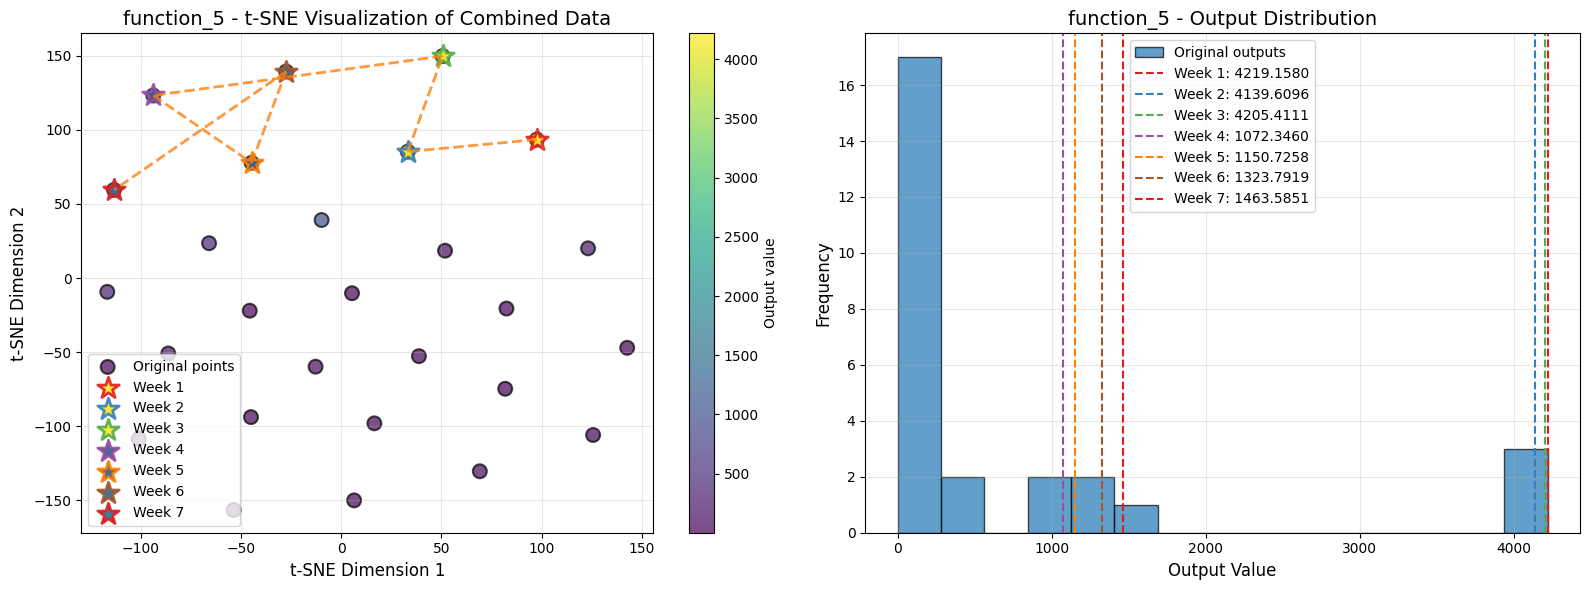

In [12]:
# Visualise past results: show all week 1–7 points before deciding on next evaluation
plot_tsne_with_distribution(
    X_observed, y_observed,
    week7_input, week7_output,
    function_name,
    weekly_points=[
        (week1_input, week1_output, "Week 1"),
        (week2_input, week2_output, "Week 2"),
        (week3_input, week3_output, "Week 3"),
        (week4_input, week4_output, "Week 4"),
        (week5_input, week5_output, "Week 5"),
        (week6_input, week6_output, "Week 6"),
        (week7_input, week7_output, "Week 7"),
    ],
    connect_points=True,
    connect_color="tab:orange",
    random_state=42
)

In [13]:
# Run exploitative BO (β=0) and suggest next point
n_dims = X_observed.shape[1]
bounds = [[0.0, 1.0]] * n_dims

bo = SimpleBayesianOptimization(bounds=bounds, n_initial=0, random_state=42)
bo.fit(X_observed, y_observed)
next_point = bo.suggest_next_point(beta=0.0)
ucb_value = bo.acquisition_ucb(next_point.reshape(1, -1), beta=0.0)[0]

formatted_point = '-'.join([f'{x:.6f}' for x in next_point])

print('=' * 60)
print('FUNCTION 5 – EXPLOITATIVE BO SUGGESTION (β=0)')
print('=' * 60)
print(f'Suggested next point: {formatted_point}')
print(f'Expected value (UCB = mean): {ucb_value:.6f}')
if flag:
    print(f"\n⚠️  WARNING: {message}")
    print("   Consider exploring or checking surrogate model quality")
print('=' * 60)

FUNCTION 5 – EXPLOITATIVE BO SUGGESTION (β=0)
Suggested next point: 0.263858-0.840374-0.969496-0.889507
Expected value (UCB = mean): 1575.327866


/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Approach for Next Evaluation (Function 5 – Exploitative BO)

For the next evaluation, we use **exploitative Bayesian Optimization** (GP + UCB with β=0): the suggested point is the one that **maximises the GP posterior mean**, i.e. where the surrogate model predicts the highest objective value.

---

### Why this approach

Function 5 is treated as a **deterministic or low-noise** objective. Under that assumption:

- The GP surrogate is a reliable predictor of the objective.
- **Exploitation** (β=0) focuses on refining the best region rather than exploring uncertain areas.
- The next point is chosen to maximise predicted performance.

---

### What we are doing

We **evaluate the objective at the BO-suggested point** above. This continues the exploitative strategy from Week 6 and updates the surrogate with the new observation for the next iteration.

In [14]:
# Save to results/ in same format as function1_next_point.json
import json

result = {
    "function_name": function_name,
    "next_point": next_point.tolist(),
    "formatted": formatted_point,
    "method": "bayesian_optimization_exploitative",
    "expected_value": float(ucb_value),
    "validation_status": status,
    "validation_message": message,
    "validation_flag": flag,
}
Path("results").mkdir(exist_ok=True)
output_path = Path("results/function5_next_point.json")
with open(output_path, "w") as f:
    json.dump(result, f, indent=2)

print('Next evaluation point (BO suggestion):', formatted_point)
print('Input vector:', next_point)
print(f"\nResult saved to: {output_path}")

Next evaluation point (BO suggestion): 0.263858-0.840374-0.969496-0.889507
Input vector: [0.263858   0.8403738  0.96949629 0.88950683]

Result saved to: results/function5_next_point.json


### Inputs/Outputs comparison table (Function 5)

Source, Input number, Output value, Distance to maximum input, Summary of progress. Proposed week 8 row uses the BO-suggested next point and UCB (mean) as estimated output.

In [15]:
import importlib
import scripts.utils.distance_utils as distance_utils
importlib.reload(distance_utils)
from scripts.utils.distance_utils import make_inputs_outputs_table

n_initial = original_inputs.shape[0]
table = make_inputs_outputs_table(
    X_observed, y_observed, n_initial,
    x_proposed=next_point,
    y_proposed=float(ucb_value),
)
display(table)

,Source,Input number,Output value,Distance to maximum input,Summary of progress
0,initial,1,64.443440,1.301488,Initial
1,initial,2,18.301380,0.717084,Initial
2,initial,3,0.112940,1.132268,Initial
3,initial,4,4.210898,0.912781,Initial
4,initial,5,258.370525,0.828509,Initial
5,initial,6,78.434389,0.923270,Initial
6,initial,7,57.571537,0.799012,Initial
7,initial,8,109.571876,1.257021,Initial
8,initial,9,8.847992,1.047738,Initial
9,initial,10,233.223610,1.039159,Initial
